In [2]:
import os
import pm4py

# Imposta i percorsi e i nomi dei case study
base_path = r"C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\case_studies"
case_studies = ["BAC", "BPI12", "bpi17_after", "bpi17_before"]

def confronta_reti(net1, net2):
    """
    Confronta due reti di Petri in base al numero di nodi/archi 
    e alle etichette delle transizioni (le attività).
    """
    t1_labels = {t.label for t in net1.transitions if t.label is not None}
    t2_labels = {t.label for t in net2.transitions if t.label is not None}

    n_t1, n_t2 = len(net1.transitions), len(net2.transitions)
    n_p1, n_p2 = len(net1.places), len(net2.places)
    n_a1, n_a2 = len(net1.arcs), len(net2.arcs)

    is_equal = (n_t1 == n_t2) and (n_p1 == n_p2) and (n_a1 == n_a2) and (t1_labels == t2_labels)
    
    differenze = []
    if not is_equal:
        if n_p1 != n_p2: differenze.append(f"Posti (Places): Rete 1 ne ha {n_p1}, Rete 2 ne ha {n_p2}")
        if n_t1 != n_t2: differenze.append(f"Transizioni (Transitions): Rete 1 ne ha {n_t1}, Rete 2 ne ha {n_t2}")
        if n_a1 != n_a2: differenze.append(f"Archi (Arcs): Rete 1 ne ha {n_a1}, Rete 2 ne ha {n_a2}")
        
        t_solo_1 = t1_labels - t2_labels
        t_solo_2 = t2_labels - t1_labels
        if t_solo_1: differenze.append(f"Attività presenti SOLO nella Rete 1: {t_solo_1}")
        if t_solo_2: differenze.append(f"Attività presenti SOLO nella Rete 2: {t_solo_2}")

    return is_equal, differenze


def calcola_metriche(log, net, im, fm):
    """Calcola Fitness, Precision (tramite alignments) e F-Score"""
    fitness_dict = pm4py.fitness_alignments(log, net, im, fm)
    fitness = fitness_dict['log_fitness'] 
    
    precision = pm4py.precision_alignments(log, net, im, fm)
    
    if (fitness + precision) > 0:
        f_score = 2 * (fitness * precision) / (fitness + precision)
    else:
        f_score = 0.0
        
    return fitness, precision, f_score


ANALISI CASE STUDY: BAC
-> Trovato diem_log_BAC.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 32429/32429 [00:14<00:00, 2175.76it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 15, Rete 2 ne ha 12
  -> Transizioni (Transitions): Rete 1 ne ha 22, Rete 2 ne ha 20
  -> Archi (Arcs): Rete 1 ne ha 44, Rete 2 ne ha 40
  -> Attività presenti SOLO nella Rete 1: {'Request completed with customer recovery', 'Request deleted'}

--- Metriche Rete 1 (diem_log_BAC.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:01<00:00, 148.14it/s]
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:00<00:00, 792.25it/s]


Fitness:   0.9159
Precision: 0.9604
F-Score:   0.9376

--- Metriche Rete 2 (BAC_best_petri_net.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:01<00:00, 139.21it/s]
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:01<00:00, 404.56it/s]


Fitness:   0.9437
Precision: 0.9035
F-Score:   0.9232

Stampo la Rete 1 (diem_log_BAC.pnml):


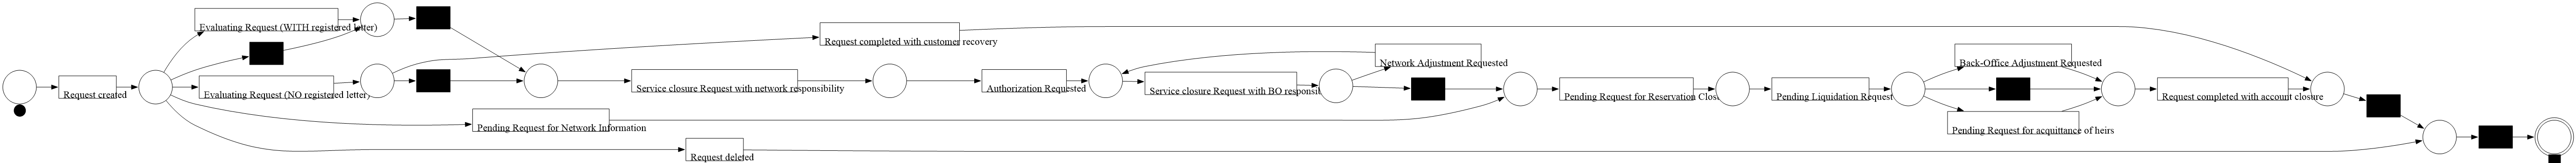


Stampo la Rete 2 (BAC_best_petri_net.pnml):


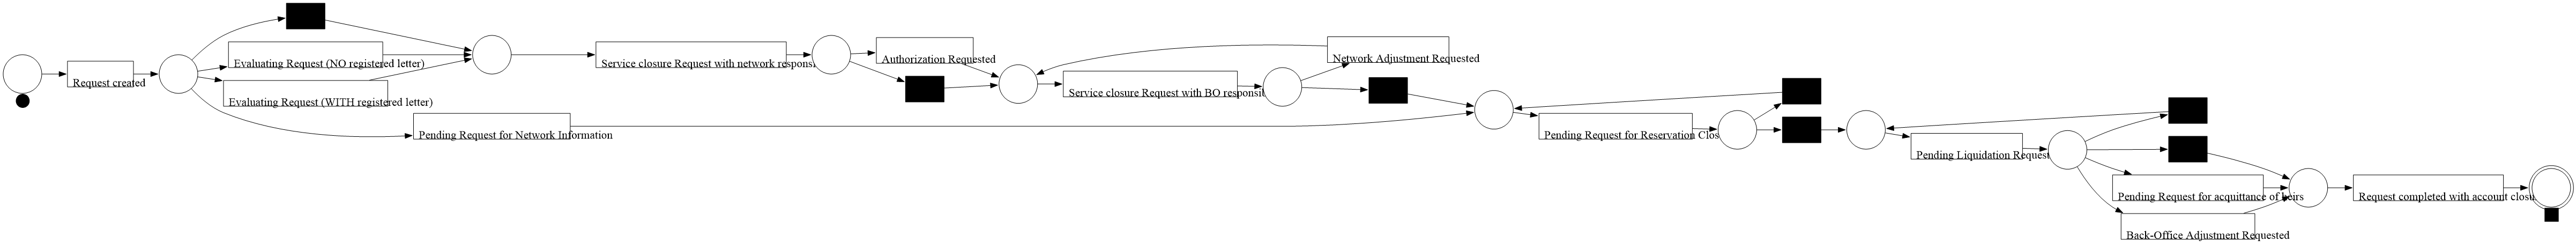




ANALISI CASE STUDY: BPI12
-> Trovato diem_log_BPI12.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 4685/4685 [00:06<00:00, 739.24it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 23, Rete 2 ne ha 27
  -> Transizioni (Transitions): Rete 1 ne ha 35, Rete 2 ne ha 45
  -> Archi (Arcs): Rete 1 ne ha 70, Rete 2 ne ha 90

--- Metriche Rete 1 (diem_log_BPI12.pnml) ---


aligning log, completed variants :: 100%|██████████| 3776/3776 [05:14<00:00, 12.01it/s]
computing precision with alignments, completed variants :: 100%|██████████| 32362/32362 [02:08<00:00, 251.82it/s]


Fitness:   0.5998
Precision: 0.7793
F-Score:   0.6779

--- Metriche Rete 2 (BPI12_best_petri_net.pnml) ---


aligning log, completed variants :: 100%|██████████| 3776/3776 [16:13<00:00,  3.88it/s]
computing precision with alignments, completed variants :: 100%|██████████| 32362/32362 [07:14<00:00, 74.49it/s] 


Fitness:   0.8099
Precision: 0.7255
F-Score:   0.7654

Stampo la Rete 1 (diem_log_BPI12.pnml):


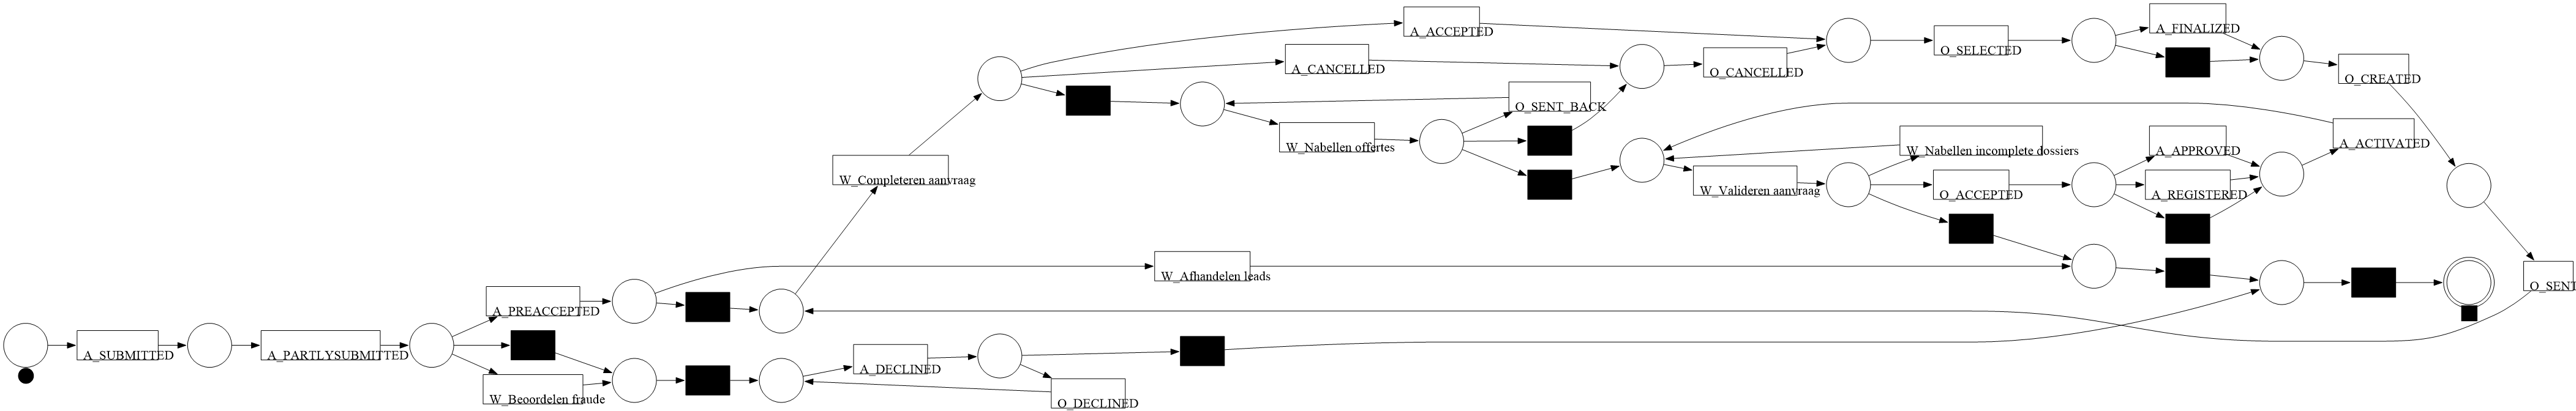


Stampo la Rete 2 (BPI12_best_petri_net.pnml):


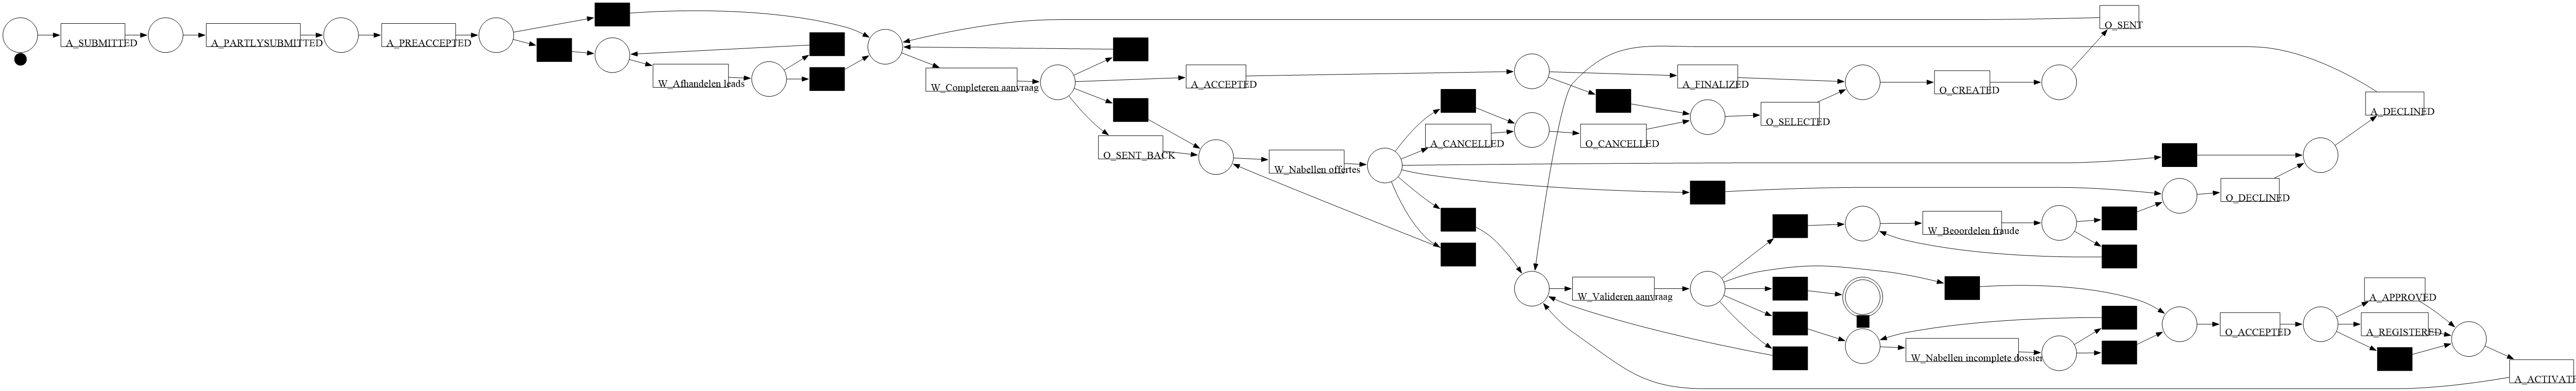




ANALISI CASE STUDY: bpi17_after
-> Trovato diem_log_bpi17_after.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 14066/14066 [00:44<00:00, 318.23it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 28, Rete 2 ne ha 31
  -> Transizioni (Transitions): Rete 1 ne ha 38, Rete 2 ne ha 52
  -> Archi (Arcs): Rete 1 ne ha 76, Rete 2 ne ha 104

--- Metriche Rete 1 (diem_log_bpi17_after.pnml) ---


aligning log, completed variants :: 100%|██████████| 3064/3064 [04:16<00:00, 11.95it/s]
computing precision with alignments, completed variants :: 100%|██████████| 14581/14581 [02:34<00:00, 94.60it/s] 


Fitness:   0.9024
Precision: 0.9277
F-Score:   0.9149

--- Metriche Rete 2 (bpi17_after_best_petri_net.pnml) ---


aligning log, completed variants :: 100%|██████████| 3064/3064 [10:30<00:00,  4.86it/s]
computing precision with alignments, completed variants :: 100%|██████████| 14581/14581 [03:06<00:00, 78.13it/s] 


Fitness:   0.9349
Precision: 0.8589
F-Score:   0.8953

Stampo la Rete 1 (diem_log_bpi17_after.pnml):


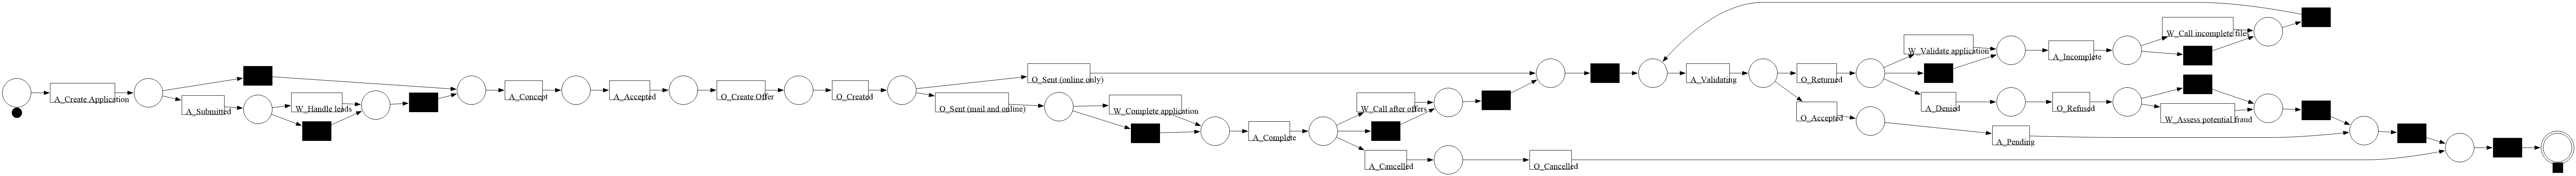


Stampo la Rete 2 (bpi17_after_best_petri_net.pnml):


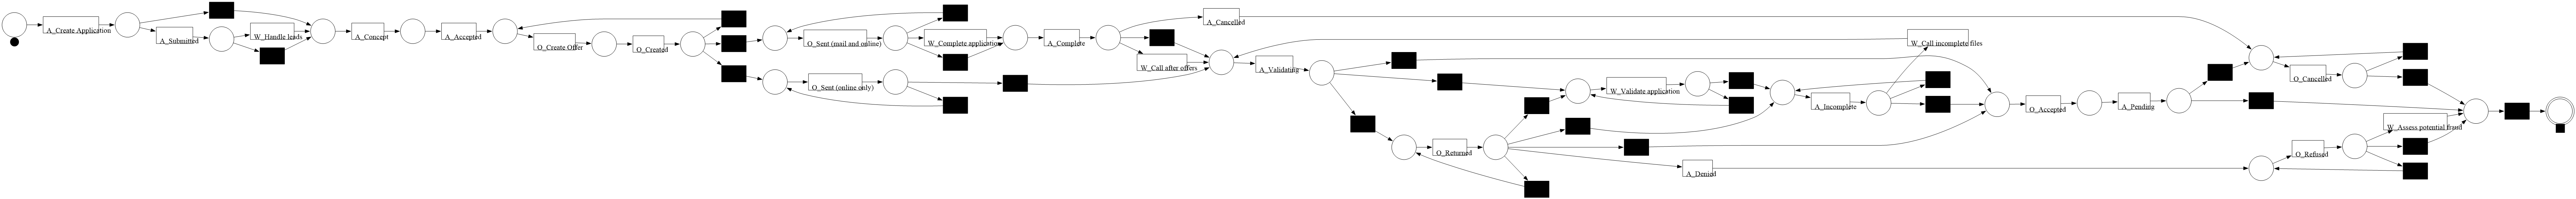




ANALISI CASE STUDY: bpi17_before
-> Trovato diem_log_bpi17_before.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 12121/12121 [00:50<00:00, 238.98it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 26, Rete 2 ne ha 33
  -> Transizioni (Transitions): Rete 1 ne ha 35, Rete 2 ne ha 55
  -> Archi (Arcs): Rete 1 ne ha 70, Rete 2 ne ha 110

--- Metriche Rete 1 (diem_log_bpi17_before.pnml) ---


aligning log, completed variants :: 100%|██████████| 2514/2514 [03:10<00:00, 13.21it/s]
computing precision with alignments, completed variants :: 100%|██████████| 13181/13181 [02:15<00:00, 97.53it/s] 


Fitness:   0.8831
Precision: 0.9439
F-Score:   0.9125

--- Metriche Rete 2 (bpi17_before_best_petri_net.pnml) ---


aligning log, completed variants :: 100%|██████████| 2514/2514 [11:33<00:00,  3.63it/s]
computing precision with alignments, completed variants :: 100%|██████████| 13181/13181 [03:10<00:00, 69.23it/s]


Fitness:   0.9544
Precision: 0.8706
F-Score:   0.9106

Stampo la Rete 1 (diem_log_bpi17_before.pnml):


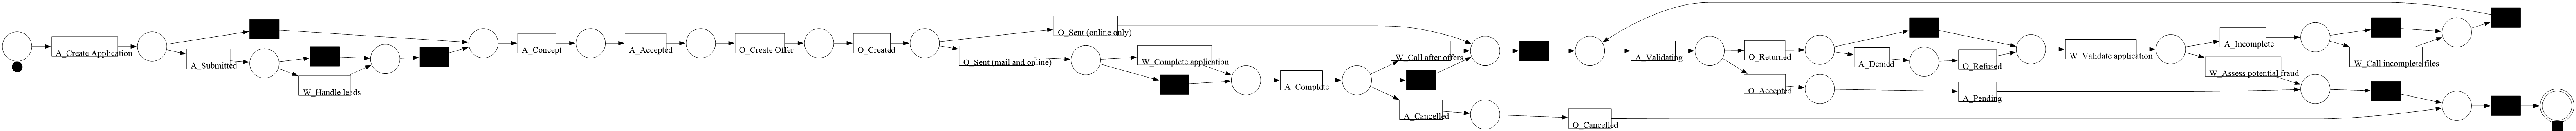


Stampo la Rete 2 (bpi17_before_best_petri_net.pnml):


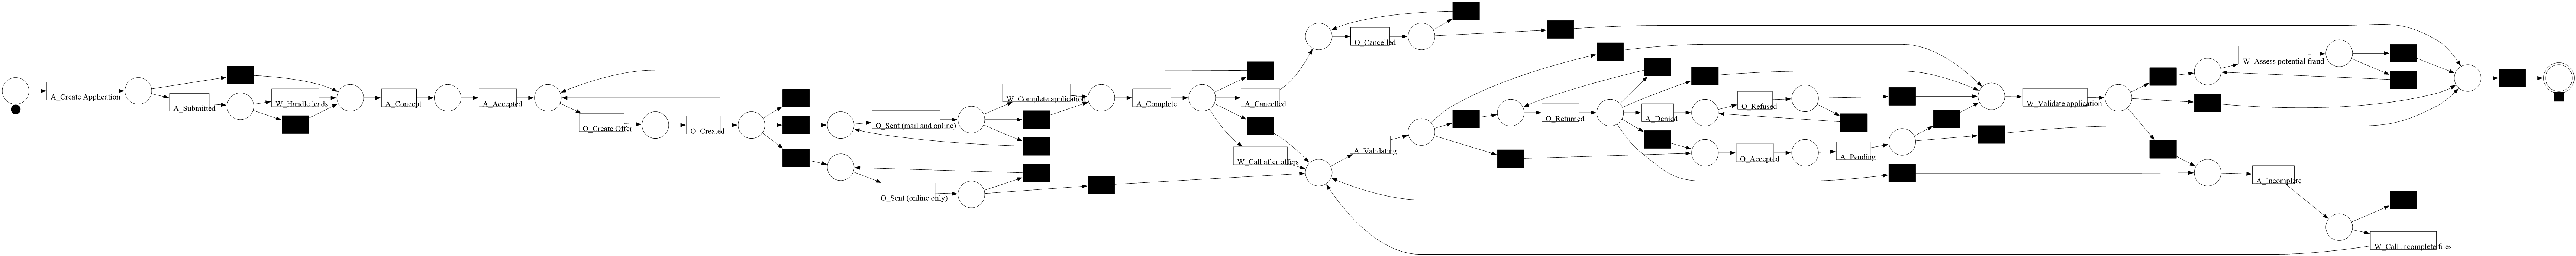

In [ ]:



# Ciclo principale su tutti i dataset
for cs in case_studies:
    print(f"\n{'='*60}")
    print(f"ANALISI CASE STUDY: {cs}")
    print(f"{'='*60}")
    
    # Costruzione dei percorsi specifici
    discovery_dir = os.path.join(base_path, cs, "discovery_output")
    log_path = os.path.join(base_path, cs, f"log_{cs}.xes")
    
    bpmn_path = os.path.join(discovery_dir, f"diem_log_{cs}.bpmn")
    net1_pnml_path = os.path.join(discovery_dir, f"diem_log_{cs}.pnml")
    net2_pnml_path = os.path.join(discovery_dir, f"{cs}_best_petri_net.pnml")
    
    # 1. CONVERSIONE DA BPMN A PNML (Se il BPMN esiste e il PNML non è già stato creato)
    if os.path.exists(bpmn_path):
        if not os.path.exists(net1_pnml_path):
            print(f"-> Trovato {os.path.basename(bpmn_path)}. Conversione in PNML in corso...")
            try:
                bpmn_graph = pm4py.read_bpmn(bpmn_path)
                net_conv, im_conv, fm_conv = pm4py.convert_to_petri_net(bpmn_graph)
                pm4py.write_pnml(net_conv, im_conv, fm_conv, net1_pnml_path)
                print("-> Conversione e salvataggio completati.")
            except Exception as e:
                print(f"Errore durante la conversione del file BPMN: {e}")
                continue
        else:
            print(f"-> Il file {os.path.basename(net1_pnml_path)} esiste già. Salto la conversione.")
    else:
        print(f"ATTENZIONE: File BPMN {os.path.basename(bpmn_path)} non trovato. Assicurati che sia nella cartella corretta.")
        # Se manca il file sorgente, passiamo al prossimo case study
        if not os.path.exists(net1_pnml_path):
            continue
    
    # 2. CARICAMENTO DEL LOG
    if not os.path.exists(log_path):
        print(f"ATTENZIONE: File di log non trovato in {log_path}. Salto...")
        continue
        
    print("\nCaricamento dell'Event Log in corso...")
    log = pm4py.read_xes(log_path)
    
    # 3. CARICAMENTO DELLE RETI PNML DA CONFRONTARE
    try:
        net1, im1, fm1 = pm4py.read_pnml(net1_pnml_path)
        net2, im2, fm2 = pm4py.read_pnml(net2_pnml_path)
    except Exception as e:
        print(f"Errore nel caricamento dei file PNML per {cs}: {e}")
        continue

    # 4. CONFRONTO STRUTTURALE
    print("\n--- Confronto Strutturale ---")
    uguali, differenze = confronta_reti(net1, net2)
    
    if uguali:
        print("Le due reti di Petri hanno la STESSA STRUTTURA.")
    else:
        print("Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:")
        for diff in differenze:
            print(f"  -> {diff}")
            
    # 5. CALCOLO METRICHE RETE 1 (diem_log)
    print(f"\n--- Metriche Rete 1 ({os.path.basename(net1_pnml_path)}) ---")
    try:
        fit1, prec1, fs1 = calcola_metriche(log, net1, im1, fm1)
        print(f"Fitness:   {fit1:.4f}")
        print(f"Precision: {prec1:.4f}")
        print(f"F-Score:   {fs1:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 1: {e}")

    # 6. CALCOLO METRICHE RETE 2 (best_petri_net)
    print(f"\n--- Metriche Rete 2 ({os.path.basename(net2_pnml_path)}) ---")
    try:
        fit2, prec2, fs2 = calcola_metriche(log, net2, im2, fm2)
        print(f"Fitness:   {fit2:.4f}")
        print(f"Precision: {prec2:.4f}")
        print(f"F-Score:   {fs2:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 2: {e}")

    # 7. VISUALIZZAZIONE RETI
    if uguali:
        print("\nStampo la rete a schermo (le reti sono identiche):")
        pm4py.view_petri_net(net1, im1, fm1)
    else:
        print(f"\nStampo la Rete 1 ({os.path.basename(net1_pnml_path)}):")
        pm4py.view_petri_net(net1, im1, fm1)
        print(f"\nStampo la Rete 2 ({os.path.basename(net2_pnml_path)}):")
        pm4py.view_petri_net(net2, im2, fm2)
        
    print("\n")

## Event Log Details
First, here is the total number of traces processed for each dataset during the parsing phase:
* **BAC:** 32,429 traces
* **BPI12:** 4,685 traces
* **bpi17_after:** 14,066 traces
* **bpi17_before:** 12,121 traces

---

## Performance Metrics Comparison
This table compares how well each Petri net models the underlying event log. **Net 1** refers to the DIEM generated nets (`diem_log_*.pnml`), while **Net 2** refers to the optimized nets (`*_best_petri_net.pnml`).

| Case Study | Network | Fitness | Precision | F-Score |
|---|---|---|---|---|
| **BAC** | Net 1 (DIEM) | 0.9159 | 0.9604 | 0.9376 |
| | Net 2 (Best) | 0.9437 | 0.9035 | 0.9232 |
| **BPI12** | Net 1 (DIEM) | 0.5998 | 0.7793 | 0.6779 |
| | Net 2 (Best) | 0.8099 | 0.7255 | 0.7654 |
| **bpi17_after** | Net 1 (DIEM) | 0.9024 | 0.9277 | 0.9149 |
| | Net 2 (Best) | 0.9349 | 0.8589 | 0.8953 |
| **bpi17_before** | Net 1 (DIEM) | 0.8831 | 0.9439 | 0.9125 |
| | Net 2 (Best) | 0.9544 | 0.8706 | 0.9106 |

---

## Structural Complexity Comparison
This table highlights the topological differences between the two models for each case study.

| Case Study | Network | Places | Transitions | Arcs |
|---|---|---|---|---|
| **BAC** | Net 1 (DIEM) | 15 | 22 | 44 |
| | Net 2 (Best) | 12 | 20 | 40 |
| **BPI12** | Net 1 (DIEM) | 23 | 35 | 70 |
| | Net 2 (Best) | 27 | 45 | 90 |
| **bpi17_after** | Net 1 (DIEM) | 28 | 38 | 76 |
| | Net 2 (Best) | 31 | 52 | 104 |
| **bpi17_before** | Net 1 (DIEM) | 26 | 35 | 70 |
| | Net 2 (Best) | 33 | 55 | 110 |

**Notable Structural Exception (BAC):** 
In the BAC case study, Net 1 contains specific activities that are entirely absent from Net 2. These unique activities are:
* *Request completed with customer recovery*
* *Request deleted*

nuove reti di petri confornto con quelle già trasformate usando convert to petri net function da pm4py

In [9]:
import os
import pm4py

# Definisci la lista di tutti i case study che devi analizzare
case_studies = ["BAC", "BPI12", "bpi17_before", "bpi17_after"] # Modifica con i nomi reali

# Imposta la cartella principale del tuo progetto usando r"" per evitare problemi con i backslash
base_dir = r"C:\Users\Utente\Desktop\tesi magistrale\Code"

print("Inizio confronto strutturale per tutti i case study...\n")

for case_study in case_studies:
    print("=" * 60)
    print(f"CASE STUDY: {case_study}")
    print("=" * 60)

    # Costruiamo i percorsi assoluti
    # Assumiamo che diem_log sia direttamente dentro la cartella "Code"
    diem_pnml_path = os.path.join(base_dir, "multi_obj", "case_studies", f"{case_study}", "discovery_output", f"diem_log_{case_study}.pnml")
    
    # Percorso esatto: C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\new_petrinet\model_BAC.pnml
    new_pnml_path = os.path.join(base_dir, "multi_obj", "new_petrinet", f"model_{case_study}.pnml")

    # Stampa i percorsi per fare un rapido debug visivo
    print(f"Cerco Rete Diem in: {diem_pnml_path}")
    print(f"Cerco Rete Nuova in: {new_pnml_path}\n")

    if os.path.exists(diem_pnml_path) and os.path.exists(new_pnml_path):
        try:
            # 1. Caricamento diretto di entrambe le Reti di Petri
            net1, im1, fm1 = pm4py.read_pnml(diem_pnml_path)
            net2, im2, fm2 = pm4py.read_pnml(new_pnml_path)

            # Estrazione dei nomi delle attività (ignorando le transizioni invisibili/None)
            labels1 = set(t.label for t in net1.transitions if t.label is not None)
            labels2 = set(t.label for t in net2.transitions if t.label is not None)

            # 2. Verifica uguaglianza esatta
            if (len(net1.places) == len(net2.places) and 
                len(net1.transitions) == len(net2.transitions) and 
                len(net1.arcs) == len(net2.arcs) and 
                labels1 == labels2):
                
                print(f"✅ Le due reti per '{case_study}' sono STRUTTURALMENTE IDENTICHE.\n")
            
            # 3. Analisi delle differenze
            else:
                print(f"❌ Le due reti per '{case_study}' sono DIVERSE. Differenze riscontrate:")
                
                if len(net1.places) != len(net2.places):
                    print(f"  -> Posti (Places): Rete Diem ({len(net1.places)}) vs Rete Nuova ({len(net2.places)})")
                if len(net1.transitions) != len(net2.transitions):
                    print(f"  -> Transizioni (Transitions): Rete Diem ({len(net1.transitions)}) vs Rete Nuova ({len(net2.transitions)})")
                if len(net1.arcs) != len(net2.arcs):
                    print(f"  -> Archi (Arcs): Rete Diem ({len(net1.arcs)}) vs Rete Nuova ({len(net2.arcs)})")
                    
                only_in_1 = labels1 - labels2
                only_in_2 = labels2 - labels1
                
                if only_in_1:
                    print(f"  -> Attività presenti SOLO nella Rete Diem: {only_in_1}")
                if only_in_2:
                    print(f"  -> Attività presenti SOLO nella Rete Nuova: {only_in_2}")
                print("\n")
                
        except Exception as e:
            print(f"⚠️ Errore durante l'elaborazione di '{case_study}': {e}\n")
            
    else:
        print(f"⚠️ ERRORE: Impossibile trovare uno o entrambi i file per '{case_study}'.")
        if not os.path.exists(diem_pnml_path):
            print(f"  -> Manca: {diem_pnml_path}")
        if not os.path.exists(new_pnml_path):
            print(f"  -> Manca: {new_pnml_path}")
        print("\n")

Inizio confronto strutturale per tutti i case study...

CASE STUDY: BAC
Cerco Rete Diem in: C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\case_studies\BAC\discovery_output\diem_log_BAC.pnml
Cerco Rete Nuova in: C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\new_petrinet\model_BAC.pnml

❌ Le due reti per 'BAC' sono DIVERSE. Differenze riscontrate:
  -> Transizioni (Transitions): Rete Diem (22) vs Rete Nuova (25)
  -> Archi (Arcs): Rete Diem (44) vs Rete Nuova (50)


CASE STUDY: BPI12
Cerco Rete Diem in: C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\case_studies\BPI12\discovery_output\diem_log_BPI12.pnml
Cerco Rete Nuova in: C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\new_petrinet\model_BPI12.pnml

❌ Le due reti per 'BPI12' sono DIVERSE. Differenze riscontrate:
  -> Posti (Places): Rete Diem (23) vs Rete Nuova (34)
  -> Transizioni (Transitions): Rete Diem (35) vs Rete Nuova (45)
  -> Archi (Arcs): Rete Diem (70) vs Rete Nuova (100)
  -> Attività pres


ANALISI CASE STUDY: BAC
-> Il file diem_log_BAC.pnml esiste già. Salto la conversione.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 32429/32429 [00:27<00:00, 1159.89it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Transizioni (Transitions): Rete 1 ne ha 22, Rete 2 ne ha 25
  -> Archi (Arcs): Rete 1 ne ha 44, Rete 2 ne ha 50

--- Metriche Rete 1 (diem_log_BAC.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:02<00:00, 93.07it/s] 
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:01<00:00, 451.68it/s]


Fitness:   0.9159
Precision: 0.9604
F-Score:   0.9376

--- Metriche Rete 2 (model_BAC.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:01<00:00, 95.86it/s]
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:01<00:00, 306.22it/s]


Fitness:   0.9713
Precision: 0.8379
F-Score:   0.8997

Stampo la Rete 1 (diem_log_BAC.pnml):


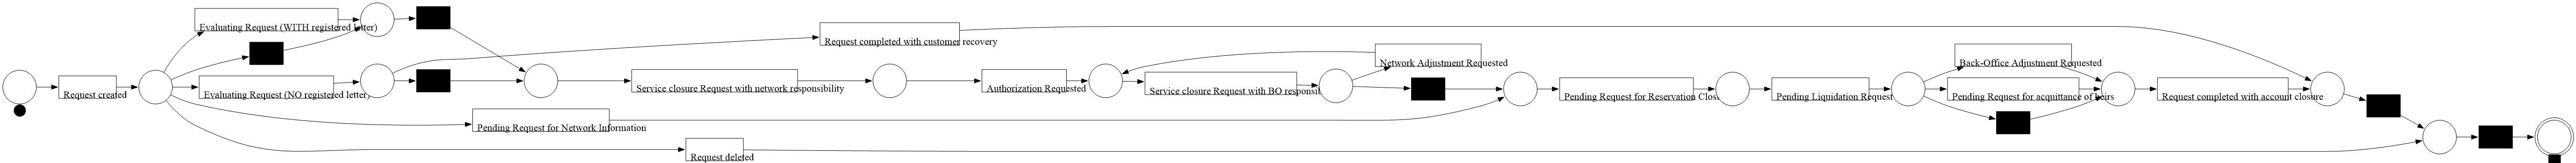


Stampo la Rete 2 (model_BAC.pnml):


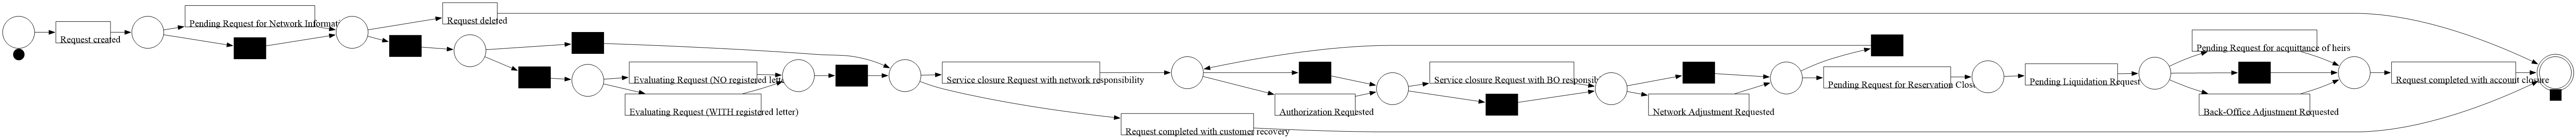




ANALISI CASE STUDY: BPI12
-> Il file diem_log_BPI12.pnml esiste già. Salto la conversione.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 4685/4685 [00:10<00:00, 459.44it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 23, Rete 2 ne ha 34
  -> Transizioni (Transitions): Rete 1 ne ha 35, Rete 2 ne ha 45
  -> Archi (Arcs): Rete 1 ne ha 70, Rete 2 ne ha 100
  -> Attività presenti SOLO nella Rete 1: {'O_CANCELLED', 'O_SENT_BACK'}

--- Metriche Rete 1 (diem_log_BPI12.pnml) ---


aligning log, completed variants :: 100%|██████████| 3776/3776 [17:22<00:00,  3.62it/s]
computing precision with alignments, completed variants :: 100%|██████████| 32362/32362 [10:33<00:00, 51.05it/s]


Fitness:   0.5998
Precision: 0.7793
F-Score:   0.6779

--- Metriche Rete 2 (model_BPI12.pnml) ---


aligning log, completed variants :: 100%|██████████| 3776/3776 [44:28<00:00,  1.42it/s]
computing precision with alignments, completed variants :: 100%|██████████| 32362/32362 [16:55<00:00, 31.85it/s]


Fitness:   0.9051
Precision: 0.2952
F-Score:   0.4452

Stampo la Rete 1 (diem_log_BPI12.pnml):


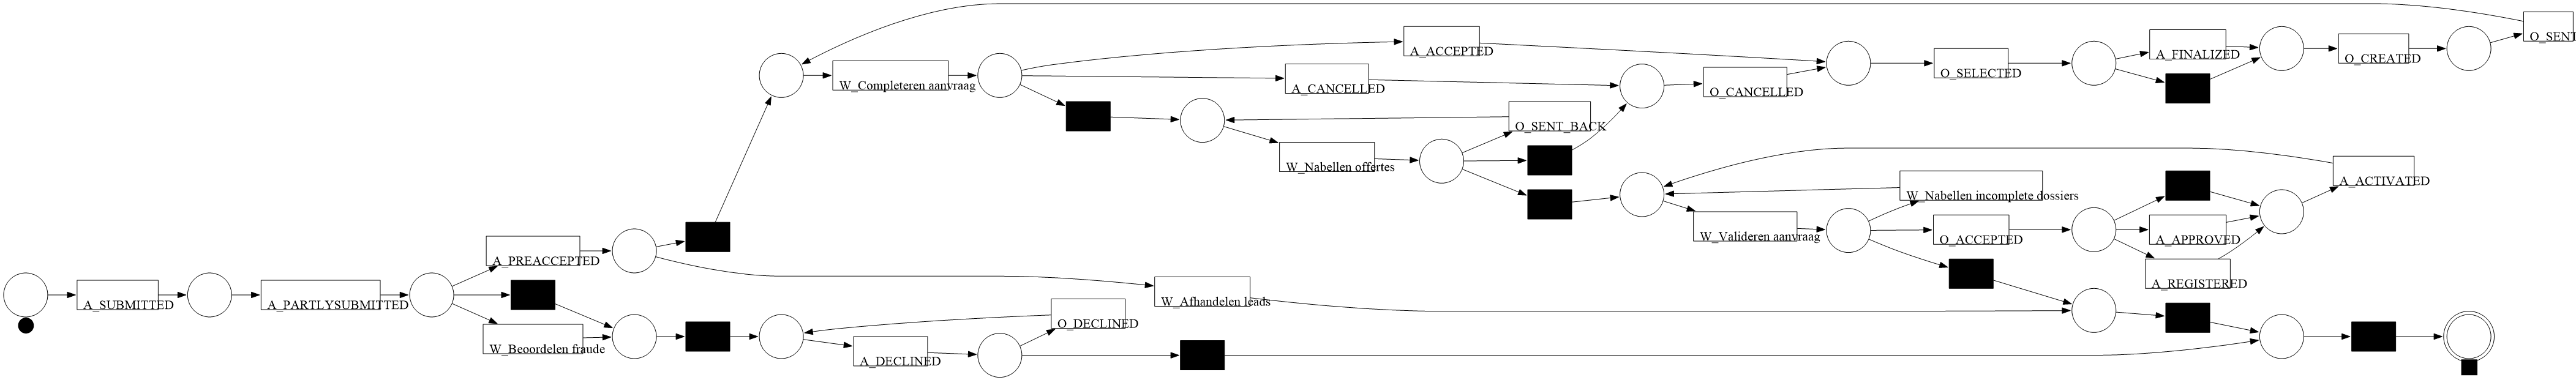


Stampo la Rete 2 (model_BPI12.pnml):


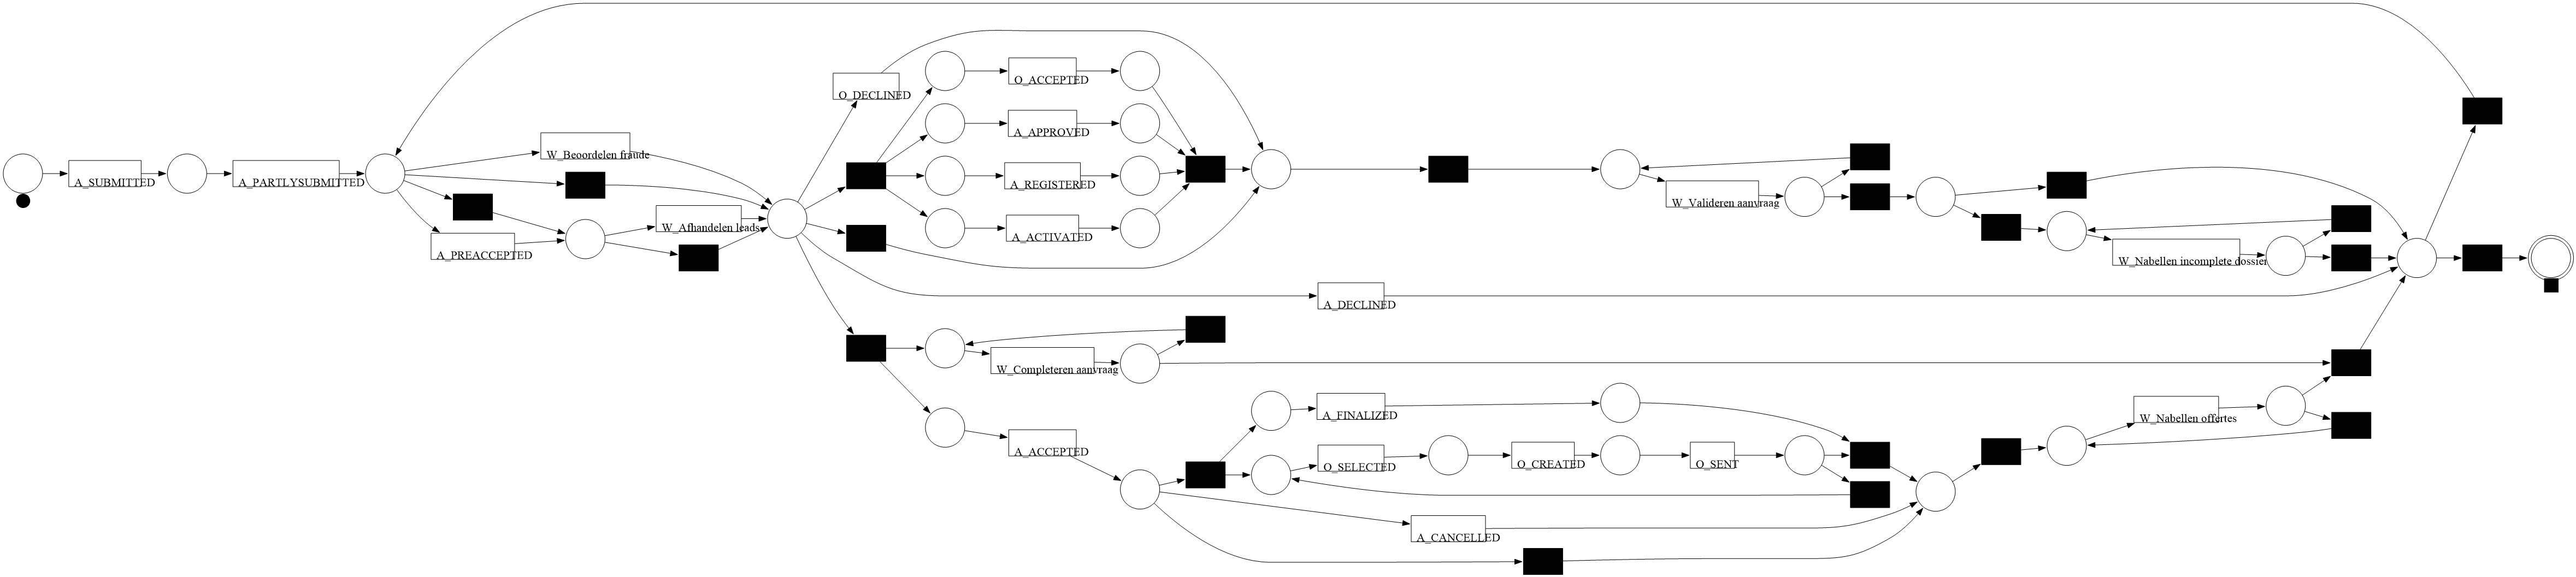




ANALISI CASE STUDY: bpi17_after
-> Il file diem_log_bpi17_after.pnml esiste già. Salto la conversione.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 14066/14066 [01:06<00:00, 212.34it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 28, Rete 2 ne ha 37
  -> Transizioni (Transitions): Rete 1 ne ha 38, Rete 2 ne ha 57
  -> Archi (Arcs): Rete 1 ne ha 76, Rete 2 ne ha 120
  -> Attività presenti SOLO nella Rete 1: {'O_Sent (online only)', 'W_Call incomplete files', 'W_Call after offers'}

--- Metriche Rete 1 (diem_log_bpi17_after.pnml) ---


aligning log, completed variants :: 100%|██████████| 3064/3064 [06:16<00:00,  8.14it/s]
computing precision with alignments, completed variants :: 100%|██████████| 14581/14581 [04:09<00:00, 58.34it/s]


Fitness:   0.9024
Precision: 0.9277
F-Score:   0.9149

--- Metriche Rete 2 (model_bpi17_after.pnml) ---


aligning log, completed variants :: 100%|██████████| 3064/3064 [29:21<00:00,  1.74it/s]
computing precision with alignments, completed variants :: 100%|██████████| 14581/14581 [06:32<00:00, 37.19it/s]


Fitness:   0.8853
Precision: 0.5930
F-Score:   0.7103

Stampo la Rete 1 (diem_log_bpi17_after.pnml):


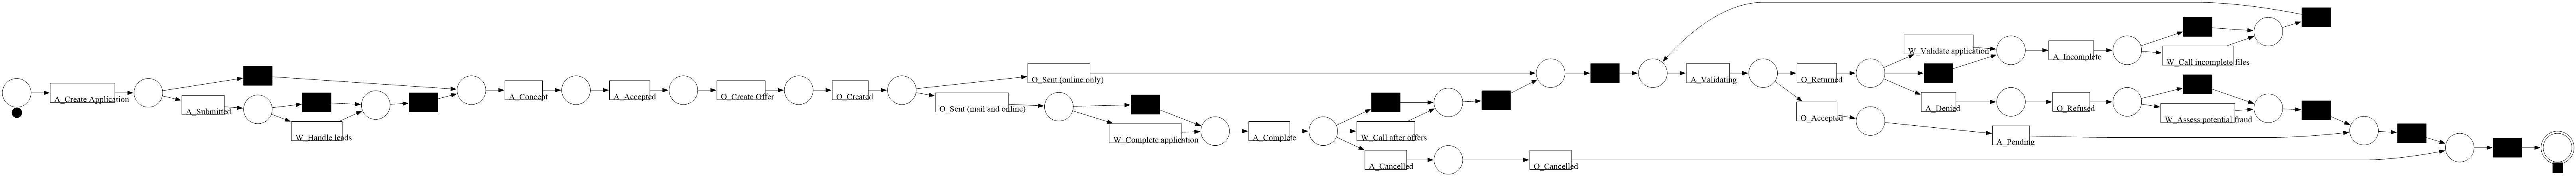


Stampo la Rete 2 (model_bpi17_after.pnml):


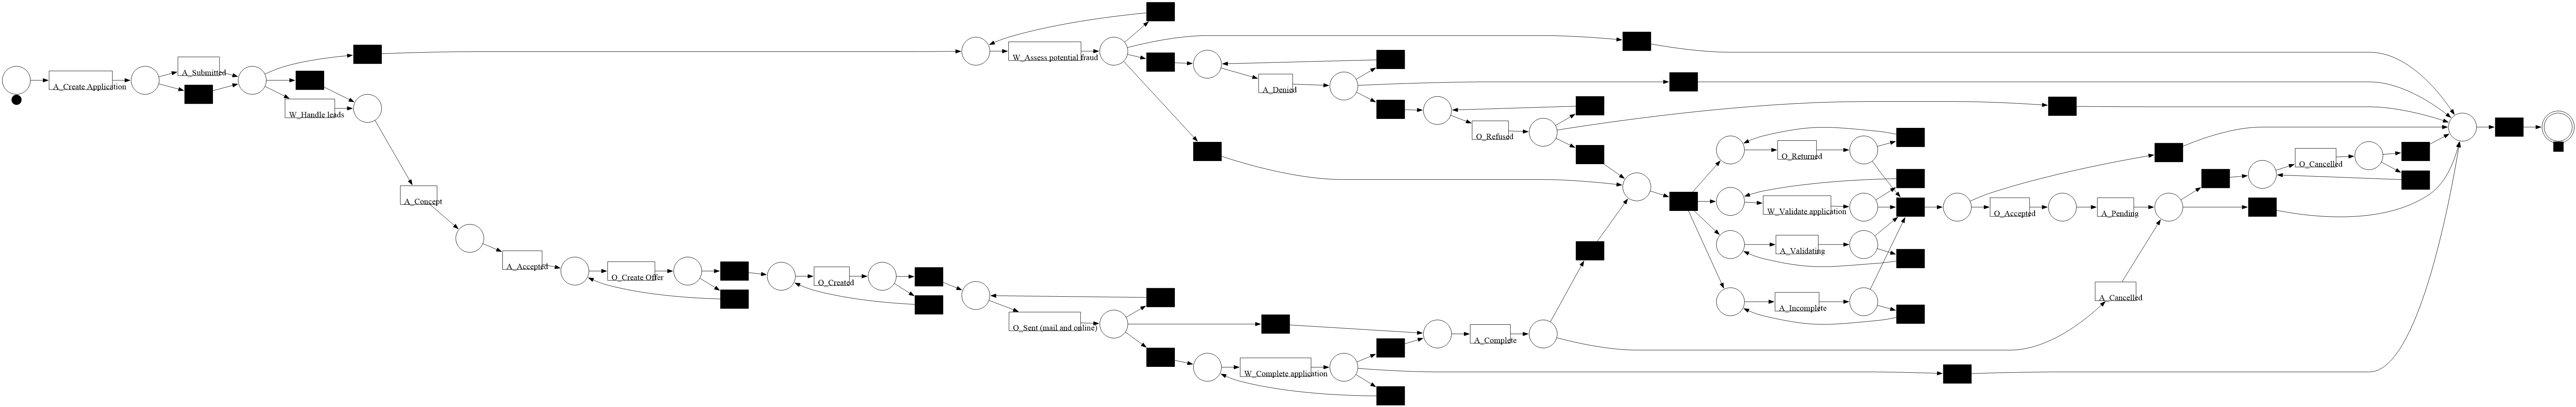




ANALISI CASE STUDY: bpi17_before
-> Il file diem_log_bpi17_before.pnml esiste già. Salto la conversione.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 12121/12121 [01:21<00:00, 148.60it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 26, Rete 2 ne ha 36
  -> Transizioni (Transitions): Rete 1 ne ha 35, Rete 2 ne ha 54
  -> Archi (Arcs): Rete 1 ne ha 70, Rete 2 ne ha 114
  -> Attività presenti SOLO nella Rete 1: {'O_Sent (online only)', 'W_Call incomplete files', 'W_Call after offers'}

--- Metriche Rete 1 (diem_log_bpi17_before.pnml) ---


aligning log, completed variants :: 100%|██████████| 2514/2514 [04:29<00:00,  9.32it/s]
computing precision with alignments, completed variants :: 100%|██████████| 13181/13181 [03:41<00:00, 59.58it/s]


Fitness:   0.8831
Precision: 0.9439
F-Score:   0.9125

--- Metriche Rete 2 (model_bpi17_before.pnml) ---


In [ ]:
import os
import pm4py

# Imposta i percorsi e i nomi dei case study
base_dir = r"C:\Users\Utente\Desktop\tesi magistrale\Code"
base_path = os.path.join(base_dir, "multi_obj", "case_studies")
case_studies = ["BAC", "BPI12", "bpi17_after", "bpi17_before"]

def confronta_reti(net1, net2):
    """
    Confronta due reti di Petri in base al numero di nodi/archi 
    e alle etichette delle transizioni (le attività).
    """
    t1_labels = {t.label for t in net1.transitions if t.label is not None}
    t2_labels = {t.label for t in net2.transitions if t.label is not None}

    n_t1, n_t2 = len(net1.transitions), len(net2.transitions)
    n_p1, n_p2 = len(net1.places), len(net2.places)
    n_a1, n_a2 = len(net1.arcs), len(net2.arcs)

    is_equal = (n_t1 == n_t2) and (n_p1 == n_p2) and (n_a1 == n_a2) and (t1_labels == t2_labels)
    
    differenze = []
    if not is_equal:
        if n_p1 != n_p2: differenze.append(f"Posti (Places): Rete 1 ne ha {n_p1}, Rete 2 ne ha {n_p2}")
        if n_t1 != n_t2: differenze.append(f"Transizioni (Transitions): Rete 1 ne ha {n_t1}, Rete 2 ne ha {n_t2}")
        if n_a1 != n_a2: differenze.append(f"Archi (Arcs): Rete 1 ne ha {n_a1}, Rete 2 ne ha {n_a2}")
        
        t_solo_1 = t1_labels - t2_labels
        t_solo_2 = t2_labels - t1_labels
        if t_solo_1: differenze.append(f"Attività presenti SOLO nella Rete 1: {t_solo_1}")
        if t_solo_2: differenze.append(f"Attività presenti SOLO nella Rete 2: {t_solo_2}")

    return is_equal, differenze

def calcola_metriche(log, net, im, fm):
    """Calcola Fitness, Precision (tramite alignments) e F-Score"""
    fitness_dict = pm4py.fitness_alignments(log, net, im, fm)
    
    # Gestione sicura della chiave (pm4py usa 'log_fitness' o 'average_trace_fitness')
    fitness = fitness_dict.get('log_fitness', fitness_dict.get('average_trace_fitness', 0.0)) 
    
    precision = pm4py.precision_alignments(log, net, im, fm)
    
    if (fitness + precision) > 0:
        f_score = 2 * (fitness * precision) / (fitness + precision)
    else:
        f_score = 0.0
        
    return fitness, precision, f_score

# Ciclo principale su tutti i dataset
for cs in case_studies:
    print(f"\n{'='*60}")
    print(f"ANALISI CASE STUDY: {cs}")
    print(f"{'='*60}")
    
    # Costruzione dei percorsi specifici
    discovery_dir = os.path.join(base_path, cs, "discovery_output")
    
    # Gestisco sia se il log si chiama BAC.xes sia se si chiama log_BAC.xes
    log_path = os.path.join(base_path, cs, f"{cs}.xes")
    if not os.path.exists(log_path):
        log_path = os.path.join(base_path, cs, f"log_{cs}.xes")
    
    bpmn_path = os.path.join(discovery_dir, f"diem_log_{cs}.bpmn")
    net1_pnml_path = os.path.join(discovery_dir, f"diem_log_{cs}.pnml")
    
    # Percorso aggiornato della rete 2 in base alla tua cartella "new_petrinet"
    net2_pnml_path = os.path.join(discovery_dir, f"model_{cs}.pnml")
    
    # 1. CONVERSIONE DA BPMN A PNML (Se il BPMN esiste e il PNML non è già stato creato)
    if os.path.exists(bpmn_path):
        if not os.path.exists(net1_pnml_path):
            print(f"-> Trovato {os.path.basename(bpmn_path)}. Conversione in PNML in corso...")
            try:
                bpmn_graph = pm4py.read_bpmn(bpmn_path)
                net_conv, im_conv, fm_conv = pm4py.convert_to_petri_net(bpmn_graph)
                pm4py.write_pnml(net_conv, im_conv, fm_conv, net1_pnml_path)
                print("-> Conversione e salvataggio completati.")
            except Exception as e:
                print(f"Errore durante la conversione del file BPMN: {e}")
                continue
        else:
            print(f"-> Il file {os.path.basename(net1_pnml_path)} esiste già. Salto la conversione.")
    else:
        print(f"ATTENZIONE: File BPMN {os.path.basename(bpmn_path)} non trovato. Assicurati che sia nella cartella corretta.")
        if not os.path.exists(net1_pnml_path):
            continue
    
    # 2. CARICAMENTO DEL LOG
    if not os.path.exists(log_path):
        print(f"ATTENZIONE: File di log non trovato in {log_path}. Salto...")
        continue
        
    print("\nCaricamento dell'Event Log in corso...")
    log = pm4py.read_xes(log_path)
    
    # 3. CARICAMENTO DELLE RETI PNML DA CONFRONTARE
    try:
        net1, im1, fm1 = pm4py.read_pnml(net1_pnml_path)
        net2, im2, fm2 = pm4py.read_pnml(net2_pnml_path)
    except Exception as e:
        print(f"Errore nel caricamento dei file PNML per {cs}: {e}")
        continue

    # 4. CONFRONTO STRUTTURALE
    print("\n--- Confronto Strutturale ---")
    uguali, differenze = confronta_reti(net1, net2)
    
    if uguali:
        print("Le due reti di Petri hanno la STESSA STRUTTURA.")
    else:
        print("Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:")
        for diff in differenze:
            print(f"  -> {diff}")
            
    # 5. CALCOLO METRICHE RETE 1 (diem_log)
    print(f"\n--- Metriche Rete 1 ({os.path.basename(net1_pnml_path)}) ---")
    try:
        fit1, prec1, fs1 = calcola_metriche(log, net1, im1, fm1)
        print(f"Fitness:   {fit1:.4f}")
        print(f"Precision: {prec1:.4f}")
        print(f"F-Score:   {fs1:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 1: {e}")

    # 6. CALCOLO METRICHE RETE 2 (Nuovo modello ottimizzato)
    print(f"\n--- Metriche Rete 2 ({os.path.basename(net2_pnml_path)}) ---")
    try:
        fit2, prec2, fs2 = calcola_metriche(log, net2, im2, fm2)
        print(f"Fitness:   {fit2:.4f}")
        print(f"Precision: {prec2:.4f}")
        print(f"F-Score:   {fs2:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 2: {e}")

    # 7. VISUALIZZAZIONE RETI
    if uguali:
        print("\nStampo la rete a schermo (le reti sono identiche):")
        pm4py.view_petri_net(net1, im1, fm1)
    else:
        print(f"\nStampo la Rete 1 ({os.path.basename(net1_pnml_path)}):")
        pm4py.view_petri_net(net1, im1, fm1)
        print(f"\nStampo la Rete 2 ({os.path.basename(net2_pnml_path)}):")
        pm4py.view_petri_net(net2, im2, fm2)
        
    print("\n")